#### **WORLD HAPPINESS** - ***Nettoyage des données***

##### *SECTION 1 - Chargement + diagnostic initial*

- Aperçu des colonnes
- Comptage valeurs manquantes
- Comptage des incohérences de régions
- Comptage des incohérences de noms de pays
- Comptage du nombre de pays distinct par année

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns
sns.set_theme(style="whitegrid")
import numpy as np
from IPython.display import Image, display

import importlib
import functions 

importlib.reload(functions)

from functions import (
    clean_name,
    report_missing_by_country,
    download_wdi,
    merge_wdi,
    generate_global_profiles,
    generate_regional_profiles,
    generate_country_profiles,
)

RAW = Path("../data/raw")
raw_files = sorted(RAW.glob("world_happiness_*.csv"))

print("Fichiers trouvés :")
for f in raw_files:
    print("-", f.name)

Fichiers trouvés :
- world_happiness_2015.csv
- world_happiness_2016.csv
- world_happiness_2017.csv
- world_happiness_2018.csv
- world_happiness_2019.csv
- world_happiness_2020.csv
- world_happiness_2021.csv
- world_happiness_2022.csv
- world_happiness_2023.csv
- world_happiness_2024.csv
- world_happiness_combined.csv


- ##### Aperçu des colonnes de chaque fichier

In [2]:
for f in raw_files:
    print(f"{f.name}")
    
    df = pd.read_csv(f, sep=";", encoding="utf-8")
    
    print(f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
    print("Colonnes :", list(df.columns),"\n")

world_happiness_2015.csv
158 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'] 

world_happiness_2016.csv
157 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'] 

world_happiness_2017.csv
155 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'] 

world_happiness_2018.csv
155 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make 

On remarque que le fichier `world_happiness_combined.csv` contient une colonne supplémentaire `Year` qui permet de regrouper l’ensemble de la décennie dans un seul fichier.

Le fichier `world_happiness_2024.csv` présente une différence au niveau du nom d’une variable,  La colonne `Happiness score` n’y figure pas et est remplacée par `Ladder score`.

- ##### Comptage valeurs manquantes

In [3]:
print("Synthèse des valeurs manquantes par fichier\n")

for f in raw_files:
    df = pd.read_csv(f, sep=";", encoding="utf-8")
    na_per_col = df.isna().sum()
    total_na = int(na_per_col.sum())
    
    if total_na == 0:
        print(f"{f.name} : aucune valeur manquante.")
    else:
        print(f"{f.name} : {total_na} valeur(s) manquante(s)")
        print(na_per_col[na_per_col > 0], "\n")

Synthèse des valeurs manquantes par fichier

world_happiness_2015.csv : aucune valeur manquante.
world_happiness_2016.csv : aucune valeur manquante.
world_happiness_2017.csv : 1 valeur(s) manquante(s)
Regional indicator    1
dtype: int64 

world_happiness_2018.csv : aucune valeur manquante.
world_happiness_2019.csv : 2 valeur(s) manquante(s)
Regional indicator    2
dtype: int64 

world_happiness_2020.csv : aucune valeur manquante.
world_happiness_2021.csv : aucune valeur manquante.
world_happiness_2022.csv : aucune valeur manquante.
world_happiness_2023.csv : 1 valeur(s) manquante(s)
Healthy life expectancy    1
dtype: int64 

world_happiness_2024.csv : aucune valeur manquante.
world_happiness_combined.csv : 3 valeur(s) manquante(s)
Regional indicator    3
dtype: int64 



Les valeurs manquantes sont peu nombreuses :
- 1 * `Regional indicator` de `world_happiness_2017.csv`
- 2 * `Regional indicator` de `world_happiness_2019.csv`
- 1 * `Healthy life expectancy` de `world_happiness_2023.csv`

On retrouve bien les valeurs manquantes de la variable `Regional indicator` dans `world_happiness_combined.csv`, 

mais pas celle de la variable `Healthy life expectancy` de `world_happiness_2023.csv`

In [4]:
print("Lignes contenant au moins une valeur manquante\n")

for f in raw_files:
    df = df = pd.read_csv(f, sep=";", encoding="utf-8")
    missing_rows = df[df.isna().any(axis=1)]
    
    if not missing_rows.empty:
        print(f"{f.name} : {len(missing_rows)} ligne(s) avec NA")
        display(missing_rows)

Lignes contenant au moins une valeur manquante

world_happiness_2017.csv : 1 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
79,87,Greece,NaN,"5,227","6,89283","0,76955",71,"0,14543",0,"0,09324"


world_happiness_2019.csv : 2 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
48,49,Cyprus,NaN,"6,0458","7,50051","0,75329",77,"0,64287","0,33664","0,08973"
118,120,Gambia,NaN,"4,5163","1,82777","0,57836",66,"0,60555","0,47478","0,3692"


world_happiness_2023.csv : 1 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
98,99,State of Palestine,Middle East and North Africa,"4,9078","5,20061","0,80811",NaN,"0,53963","0,15516","0,88085"


world_happiness_combined.csv : 3 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
394,87,Greece,NaN,"5,22700","6,89283","0,76955",71,"0,14543","0,00000","0,09324",2017
673,49,Cyprus,NaN,"6,04580","7,50051","0,75329",77,"0,64287","0,33664","0,08973",2019
743,120,Gambia,NaN,"4,51630","1,82777","0,57836",66,"0,60555","0,47478","0,36920",2019


La valeur manquante de la variable `Healthy life expectancy` pour le pays `State of Palestine` a été corrigée dans `world_happiness_combined.csv`.

Il ne reste qu'à renseigner la variable `Regional indicator` pour les pays `Greece`, `Cyprus` et `Gambia` en observant leur affectation sur les autres années.

Reste à savoir si les régions renseignées sont bien cohérentes avec les pays associés



- ##### Comptage des incohérences de régions

In [5]:
COMBINED = RAW / "world_happiness_combined.csv"
df_combined_raw = pd.read_csv(COMBINED, sep=";", encoding="utf-8")

# Nombre de régions distinctes par pays
region_check = (
    df_combined_raw.groupby("Country")["Regional indicator"]
      .nunique()
      .reset_index()
      .rename(columns={"Regional indicator": "Nb_regions"})
)

# Pays dont la région change au moins une fois
pays_incoherents = region_check[region_check["Nb_regions"] > 1]["Country"].tolist()

print(len(pays_incoherents), "Pays avec au moins 2 régions différentes selon les années :")
print(pays_incoherents)

print("\nDétails des incohérences :")
for country in pays_incoherents:
    temp = (
        df_combined_raw[df_combined_raw["Country"] == country]
        .sort_values("Year")[["Country", "Year", "Regional indicator"]]
    )
    print(f"\n{country} :")
    print(temp.to_string(index=False))

25 Pays avec au moins 2 régions différentes selon les années :
['Argelia', 'Cyprus', 'Czech Republic', 'Czechia', 'Estonia', 'Georgia', 'Greece', 'Hungary', 'Laos', 'Latvia', 'Lithuania', 'Macedonia', 'Maldives', 'Mauritania', 'Moldova', 'Montenegro', 'North Cyprus', 'Poland', 'Romania', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'Sudan', 'Ukraine']

Détails des incohérences :

Argelia :
Country  Year           Regional indicator
Argelia  2017 Middle East and North Africa
Argelia  2018 Middle East and North Africa
Argelia  2019 Middle East and North Africa
Argelia  2020 Middle East and North Africa
Argelia  2021           Sub-Saharan Africa
Argelia  2022           Sub-Saharan Africa
Argelia  2023           Sub-Saharan Africa
Argelia  2024           Sub-Saharan Africa

Cyprus :
Country  Year           Regional indicator
 Cyprus  2015               Western Europe
 Cyprus  2016               Western Europe
 Cyprus  2017               Western Europe
 Cyprus  2018 Middle East and North 

Ce dataset Kaggle comporte beaucoup d'erreurs d'affectation de région donc certaines qui sont grossières :
- `Sudan` est localisée en `Western Europe`
- `Greece` est localisée en `Western Europe` puis en `Middle East and North Africa`
- `Laos` est localisée en `Southeast Asia` puis en `East Asia` puis en `Sub-Saharan Africa`

Au vu de la qualité des données, une inspection des noms de pays doit avoir lieu.

- ##### Comptage des incohérences de noms de pays

In [6]:
# Comptage du nombre d'occurrences par pays
country_counts = (
    df_combined_raw["Country"]
    .value_counts()
    .sort_values()
)

print("Pays avec le moins d'occurrences :\n")
print(country_counts.head(15))

Pays avec le moins d'occurrences :

Country
Djibouti              1
Oman                  1
Puerto Rico           1
Trinidad & Tobago     1
Congo                 1
State of Palestine    1
Turkiye               2
Algeria               2
Suriname              2
Somaliland region     2
Eswatini              2
Maldives              2
North Cyprus          3
Czechia               3
Belize                3
Name: count, dtype: int64


Certains pays n'apparaissent pas de manière régulière dans le jeu de données.
On observe aussi plusieurs incohérences liées au nom des pays :
- `Congo (Brazzaville)` et `Congo (Kinshasa)` n'ont pas la bonne appellation et `Congo` apparait une fois dans le jeu de données, sans qu'on sache lequel des deux pays il désigne.
- `Czech Republic` et `Czechia` correspondent au même pays mais sont comptés séparément car le pays a changé de nom durant la décennie, tout comme `Macedonia` et `North Macedonia`, `Turkey` et `Turkiye`, 
- L'impact géopolitique se voit aussi sur certains pays qui apparaissent sous plusieurs noms, comme `Hong Kong` et `Hong Kong S.A.R. of China`, `Taiwan` et `Taiwan Province of China` ou encore `Palestinian Territories` et `State of Palestine`.

Afin de mieux comprendre l’ampleur des incohérences de ce dataset, il est utile d’observer comment le nombre de pays évolue d’une année à l’autre.

- ##### Comptage du nombre de pays distinct par année

In [7]:
countries_year = df_combined_raw.groupby("Year")["Country"].nunique()
print("Nombre de pays par année :\n", countries_year)

total_unique_countries = df_combined_raw["Country"].nunique()
print(f"\n==================\nNombre total de pays différents : {total_unique_countries}")

countries_all_years = (
    df_combined_raw.groupby("Country")["Year"]
    .nunique()
    .reset_index()
)
max_years = df_combined_raw["Year"].nunique()
countries_all_years = countries_all_years[countries_all_years["Year"] == max_years]["Country"].tolist()

print(f"\n==================\nSeul {len(countries_all_years)} pays apparaissent chaque année ({max_years} années au total).")

Nombre de pays par année :
 Year
2015    158
2016    157
2017    155
2018    155
2019    155
2020    152
2021    148
2022    145
2023    137
2024    140
Name: Country, dtype: int64

Nombre total de pays différents : 175

Seul 121 pays apparaissent chaque année (10 années au total).


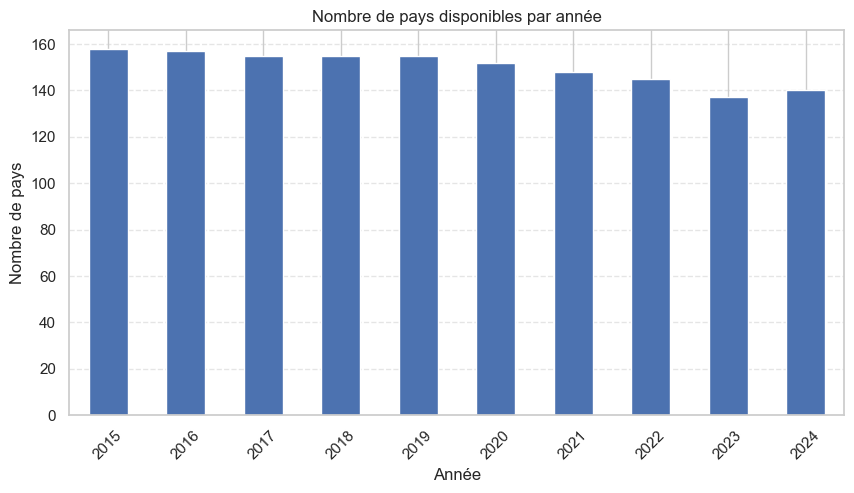

In [8]:
plt.figure(figsize=(10, 5))
countries_year.plot(kind="bar")
plt.title("Nombre de pays disponibles par année")
plt.xlabel("Année")
plt.ylabel("Nombre de pays")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Le nombre de pays n'est pas égal pour chaque année, et diminue au fil du temps, `passant de 158 pays en 2015 à 140 en 2024`.

Sur les 175 pays présents dans l’ensemble des données, `seuls 121 sont disponibles chaque année`. Cela signifie que plus de 50 pays n’apparaissent pas régulièrement, soit en raison d’un manque de données, soit à cause d’incohérences dans l’enregistrement des noms.

##### Conclusion de la Section 1

L’exploration du jeu de données met en évidence plusieurs problèmes :

- des `valeurs manquantes` dans quelques fichiers
- des `incohérences` dans l’affectation des régions (parfois totalement fausses)
- des `variations de noms` pour un même pays, liées soit à des changements officiels, soit à des choix géopolitiques ou des erreurs d’écriture
- un `nombre de pays inégal` selon les années

##### *SECTION 2 - Nettoyage des données*

- Correction des NA
- Correction des attributions des régions
- Correction des noms des pays
- Filtrage des pays présents pour toute la décennie
- Correction des nom de variable
- Observation de l'évolution des valeurs des variables
- Correction des variables (`Perceptions of corruption` et `GDP per capita`)
- Ajout de nouvelles variables

Les traitements se feront uniquement sur le fichier `world_happiness_combined.csv`

- ##### Correction des NA

In [9]:
df_combined_raw[df_combined_raw.isna().any(axis=1)][["Country", "Year", "Regional indicator", "Healthy life expectancy"]]

,Country,Year,Regional indicator,Healthy life expectancy
394,Greece,2017,NaN,71
673,Cyprus,2019,NaN,77
743,Gambia,2019,NaN,66


Les seules valeurs manquantes sont issues de la variable `Regional indicator`. Plutôt que de corriger ces cas individuellement, on va appliquer une harmonisation globale des régions par pays, ce qui permettra à la fois de traiter les NA et les erreurs d’affectation.

- ##### Correction des noms des pays


In [10]:
# Harmonisation des noms de pays
df_combined_raw["Country"] = df_combined_raw["Country"].apply(clean_name)

country_counts_clean = (
    df_combined_raw["Country"]
    .value_counts()
    .sort_values()
)

print("Pays avec le moins d'occurrences après harmonisation :\n")
print(country_counts_clean.head(10))

Pays avec le moins d'occurrences après harmonisation :

Country
Djibouti             1
Oman                 1
Congo                1
Puerto Rico          1
Somaliland region    2
Suriname             2
Maldives             2
North Cyprus         3
Belize               3
Angola               4
Name: count, dtype: int64


On constate que, même après harmonisation des noms de pays, certains pays n’apparaissent que très rarement dans le jeu de données. 

Par exemple, `Djibouti`, `Oman`, `Congo` ou `Puerto Rico` ne sont présents qu’une seule fois sur la période 2015–2024, tandis que d’autres comme `Somaliland region`, `South Sudan`, `Bhutan` ou `Qatar` n’apparaissent que quelques années.

Il y a des cas difficiles à traiter :
- `Congo`, `Congo (Brazzaville)` et `Congo (Kinshasa)`
- `Somaliland region`, qui correspond à un territoire partiellement reconnu et traité de manière spécifique dans les données.

Ces pays à faible nombre d’occurrences posent problème, ils ne permettent pas de suivre l’évolution des indicateurs sur l’ensemble de la décennie. 


- ##### Correction des attributions des régions

Afin d’éviter les erreurs de région présentes dans le dataset Kaggle (par exemple `Sudan` classé en `Western Europe`), le remplacement complet de la variable `Regional indicator` par une classification standard issue de la `Banque mondiale`.

Concrètement, la liste officielle des pays et de leurs régions a été recupérée via l’API `Country` de la `Banque mondiale`, harmonisé les noms de pays avec ceux du World Happiness Report, puis fusionné cette table avec notre jeu de données. 

Chaque pays est désormais associé à une région unique, conforme à la classification World Bank.

In [11]:
unsd = pd.read_csv("../data/raw/regions.csv", sep=";")

unsd = unsd.rename(columns={
    "Country or Area": "Country",
    "Sub-region Name": "region"
})
unsd["Country"] = unsd["Country"].apply(clean_name)

if "Regional indicator" in df_combined_raw.columns:
    df_combined_raw = df_combined_raw.drop(columns=["Regional indicator"])

df_combined_raw = df_combined_raw.merge(
    unsd[["Country", "region"]],
    on="Country",
    how="left"
)

missing_region = df_combined_raw[df_combined_raw["region"].isna()]["Country"].unique()
print("Pays sans région UNSD :")
for c in sorted(missing_region):
    print("-", c)
print("\nNombre total :", len(missing_region))

Pays sans région UNSD :
- Kosovo
- Laos
- North Cyprus
- Republic of the Congo
- Somaliland region
- Taiwan

Nombre total : 6


Seul 6 pays n'ont pas de régions affectés via le jeu de données, on rentre le reste à la main :

In [12]:
region_mapping = {
    "Kosovo": "Southern Europe",
    "Laos": "South-Eastern Asia",
    "North Cyprus": "Western Asia",
    "Republic of the Congo": "Middle Africa",
    "Somaliland region": "Eastern Africa",
    "Taiwan": "Eastern Asia",
}

mask_missing = df_combined_raw["region"].isna()

df_combined_raw.loc[mask_missing, "region"] = (
    df_combined_raw.loc[mask_missing, "Country"]
        .map(lambda c: region_mapping.get(c, None))
)

Chaque pays est désormais associé à une seule région. Cela corrige à la fois les erreurs d’affectation et les trois valeurs manquantes initialement détectées.

In [13]:
# Nombre d'années distinctes par pays
country_years = (
    df_combined_raw.groupby("Country")["Year"]
            .nunique()
            .reset_index()
            .rename(columns={"Year": "Nb_annees"})
)

# comparaison
nb_pays_all = df_combined_raw["Country"].nunique()

print(f"df_combined_raw : {nb_pays_all} pays")

df_combined_raw : 166 pays


- ##### Correction des nom de variable

Afin de simplifier la manipulation des données, les variables ont été renommées avec des noms plus courts et sans espace.


In [14]:
rename_cols = {
    "Ranking": "rank",
    "Country": "country",
    "Happiness score": "happiness_score",         
    "GDP per capita": "gdp_per_capita",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom_to_choose",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption_perception",
    "Year": "year"
}

df_combined_raw = df_combined_raw.rename(columns=rename_cols)

- ##### Observation de l'évolution des valeurs des variables

Un profil de chaque variable va nous permettre de voir si les variables n'ont pas de valeurs incohérentes.

In [15]:
from var_config import make_config

PROFIL = "../figure/profil"

ACTIVE_VARS = [
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_choose",
    "generosity",
    "corruption_perception",
]

VAR_CONFIG, COLS_NUM = make_config(ACTIVE_VARS)

In [16]:
for c in COLS_NUM:
    if c in df_combined_raw.columns:
        df_combined_raw[c] = (
            df_combined_raw[c]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        df_combined_raw[c] = pd.to_numeric(df_combined_raw[c], errors="coerce")

In [42]:
print("génération des profils mondiaux")
generate_global_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL)

print("génération des profils régionaux")
generate_regional_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL)

# Afin d'accélerer la génération des graphiques, on pré-sélectionne les pays souhaités
print("génération des profils nationales")
generate_country_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL)

génération des profils mondiaux


KeyError: "Columns not found: 'healthy_life_expectancy', 'social_support', 'corruption_perception', 'gdp_per_capita'"

Ces graphiques mettent en lumière un problème de cohérence du jeu de données Kaggle.

La variable `corruption_perception` (ou Perceptions of corruption) présente des valeurs incohérentes pour plusieurs pays et années. Par exemple, la Finlande a pour valeur : 

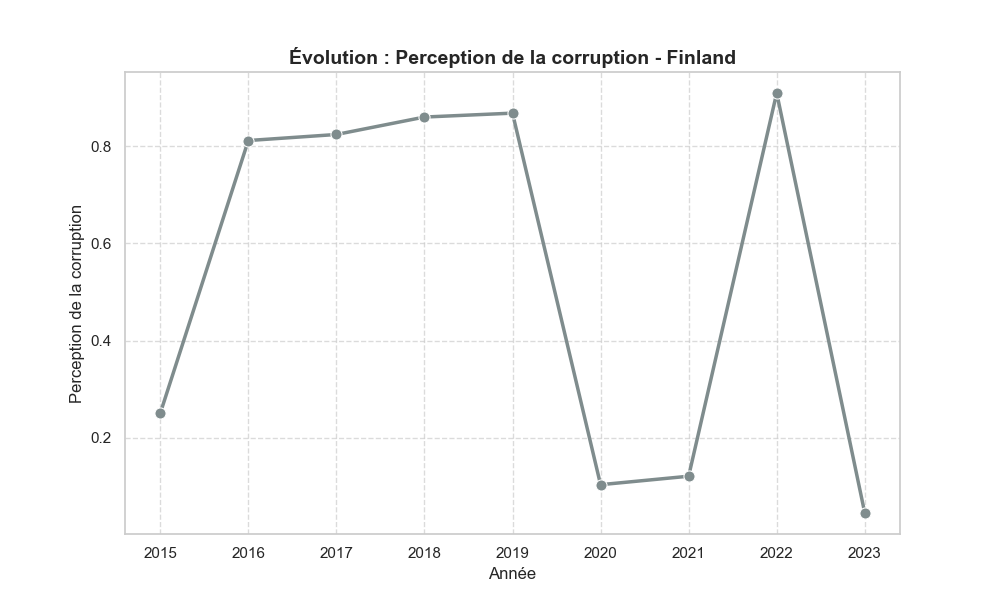

In [17]:
display(Image(filename="../figure/profil/country/Finland/Finland_corruption_perception.png"))

Ces variations brusques ne correspondent pas aux valeurs publiées dans les différents rapports officiels où les évolutions sont généralement stables.

Les variables `gdp_per_capita` et `healthy_life_expectancy` ont elles aussi un profil qui n'est pas cohérent :

In [ ]:
display(Image(filename="../figure/profil/global/mean_gdp_per_capita.png"))

In [ ]:
display(Image(filename="../figure/profil/global/mean_healthy_life_expectancy.png"))

- ##### Correction des variables : `Perceptions of corruption`

La variable issue du dataset Kaggle `Perceptions of corruption` étant incohérente et les données Gallup (à l'origine des données Kaggle) n’étant pas disponibles gratuitement, le choix d'utiliser l’indice `Corruption Perceptions Index` de Transparency International a été pris.

Cela permet de disposer d’une mesure de la corruption fiable et cohérente sur la décennie 2015–2024. 

Cependant la variable `Perceptions of corruption` issues du World Happiness Report, correspondait à la moyenne du nombre de citoyens repondant "Oui" aux 2 questions suivantes : 
- « Dans ce pays, peut-on faire confiance au gouvernement ? » 
- « Peut-on faire confiance aux entreprises ? » 

On avait donc une perception citoyenne de corruption dont les valeurs étaient comprises entre 0 et 1. 

Tandis que le `Corruption Perceptions Index` de Transparency International, est une agrégation de plusieurs rapport d’experts (Banque mondiale, Bertelsmann, FMI, etc...), transformée sur une échelle 0 à 100. C'est une évaluation institutionnelle de la corruption dans le secteur public. 

Ces deux indicateurs ne capturent donc pas exactement le même aspect du phénomène. Le premier mesure la confiance des citoyens, tandis que le second mesure le niveau attendu de corruption selon des panels d’experts. Leur rôle sur le bonheur n'est donc pas le même.

In [18]:
# Jeu de données Corruption Perceptions Index
df_cpi = pd.read_csv("../data/raw/ti-corruption-perception-index.csv")

# Nettoyage des noms de variables pour Entity, Code, Year, CPI
df_cpi = df_cpi.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Corruption Perceptions Index": "cpi"
})

In [19]:
df_cpi["country"] = df_cpi["country"].apply(clean_name)

df_merged_cpi = df_combined_raw.merge(
    df_cpi[["country", "year", "cpi"]],
    on=["country", "year"],
    how="left"
)

report_missing_by_country(df_merged_cpi, "cpi", label="CPI")

Pays sans CPI :
- Belize (années manquantes : 2016, 2017, 2018)
- Eswatini (années manquantes : 2015)
- North Cyprus (années manquantes : 2015, 2016, 2017)
- Puerto Rico (années manquantes : 2016)
- Republic of the Congo (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2023, 2024)
- Somaliland region (années manquantes : 2015, 2016)
- State of Palestine (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023)

Nombre total : 7


In [20]:
missing_cpi_countries = df_merged_cpi[df_merged_cpi["cpi"].isna()]["country"].unique()
df_merged_cpi = df_merged_cpi[~df_merged_cpi["country"].isin(missing_cpi_countries)]
df_combined_raw = df_merged_cpi.drop(columns=["corruption_perception"])

- ##### Correction des variables : `healthy_life_expectancy`

La variable `healthy_life_expectancy` est composé majoritairement de valeurs incohérentes et peu credibles. On va appliquer le jeu de données Life Expectancy de OWID afin d'avoir précisement par pays et année, l'esperance de vie moyenne d'un citoyen.

Ce jeu de donnée n'est disponible pas en 2024. En appliquant ces nouvelles valeurs, nos données serait alors répartir sur 9 années de 2015 à 2023. 

In [21]:
YEAR_MIN, YEAR_MAX = 2015, 2023

# Jeu de données Life Expectancy
df_life_exp = pd.read_csv("../data/raw/owid-life-expectancy.csv")

# Nettoyage des noms de variables pour Entity, Year, Period life expectancy at birth
df_life_exp = df_life_exp.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Period life expectancy at birth": "life_expectancy"
})

In [22]:
df_life_exp["country"] = df_life_exp["country"].apply(clean_name)
df_life_exp = df_life_exp[df_life_exp["year"].between(YEAR_MIN, YEAR_MAX)]

df_combined_raw = df_combined_raw[df_combined_raw["year"].between(YEAR_MIN, YEAR_MAX)].copy()

df_merged_life_exp = df_combined_raw.merge(
    df_life_exp[["country", "year", "life_expectancy"]],
    on=["country", "year"],
    how="left"
)

report_missing_by_country(df_merged_life_exp, "life_expectancy", label="espérance de vie (OWID)")

Aucune valeur manquante pour espérance de vie (OWID).


In [23]:
df_combined_raw = df_merged_life_exp.drop(columns=["healthy_life_expectancy"])

- ##### Correction des variables : `gdp_per_capita`

La variable `GDP per capita` du dataset Kaggle présente des incohérences importantes entre les années, rendant son utilisation peu fiable. Pour garantir la rigueur des résultats, cette variable est recalculée.

Par commencer, il est important de noter que cette variable ne correspond pas a un "simple" PIB par habitant, mais plutot au `PIB par habitant en Parité de Pouvoir d’Achat (PPP), exprimé en dollars internationaux constants de 2017`, dans les World Development Indicators de la Banque mondiale (indicateur NY.GDP.PCAP.PP.KD).

Afin d’obtenir une mesure cohérente et comparable entre pays et au cours de la décennie, les données ont été extraites directement depuis l’API de la Banque mondiale, puis transformées selon la méthodologie utilisée dans le World Happiness Report :

- récupération du PIB PPP constant par habitant pour les années 2015 à 2023 
- application du logarithme naturel, comme dans le WHR, pour obtenir gdp_log 

In [24]:
indicator = "NY.GDP.PCAP.PP.KD"
df_wdi = download_wdi(indicator, start=YEAR_MIN, end=YEAR_MAX)
df_wdi = df_wdi.rename(columns={indicator: "gdp_ppp_constant"})

In [25]:
df_wdi.loc[df_wdi["gdp_ppp_constant"] <= 0, "gdp_ppp_constant"] = np.nan
df_wdi["gdp_log"] = np.log(df_wdi["gdp_ppp_constant"])

df_merged_gdp = df_combined_raw.merge(
    df_wdi[["country", "year", "gdp_log"]],
    on=["country", "year"],
    how="left"
)

report_missing_by_country(df_merged_gdp, "gdp_log", label="gdp_log (WDI)")

Pays sans gdp_log (WDI) :
- Congo (années manquantes : 2022)
- South Sudan (années manquantes : 2016, 2017, 2018, 2019, 2020)
- Taiwan (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023)
- Venezuela (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023)
- Yemen (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022)

Nombre total : 5


In [26]:
missing_gdp_countries = df_merged_gdp.loc[df_merged_gdp["gdp_log"].isna(), "country"].unique()
df_combined_raw = df_merged_gdp[~df_merged_gdp["country"].isin(missing_gdp_countries)].copy()
df_combined_raw = df_combined_raw.drop(columns=["gdp_per_capita"])

- ##### Correction des variables : `social_support`

Les données Kaggle de cette variable sont erronées. En effet, on remarque un pic anormal en 2018. Aucune variable de subtitue n'a été trouvé pour la remplacer, cette variable est donc supprimé.

In [27]:
df_combined_raw = df_combined_raw.drop(columns=["social_support"])

- ##### Ajout des nouvelles variables

Pour enrichir l’analyse du bonheur, plusieurs indicateurs socio-démographiques et économiques ont été intégrés depuis les World Development Indicators (WDI). Les variables retenues présentent l’avantage d’être parfaitement complètes sur la période 2015–2024, sans valeurs manquantes ou presque, et cohérentes pour l’ensemble des pays. 

Les variables sélectionnées sont :

- `active_rate` (SP.POP.1564.TO.ZS) : part de la population âgée de 15 à 64 ans, représentant la population active

- `urban_rate` (SP.URB.TOTL.IN.ZS) : taux d’urbanisation, indicateur de la population vivant en zone urbaine

- `unemp_rate` (SL.UEM.TOTL.ZS) : taux de chômage total, variable économique interressante pour l’analyse du bien-être.

Ces indicateurs présentent une couverture quasi parfaite, s’intègrent sans nécessiter de nettoyage supplémentaire et permettent de mieux comprendre le score de bonheur par pays. 

In [ ]:
# WDI - Unemployment rate
df_combined_raw = merge_wdi(
    df_combined_raw,
    indicator="SL.UEM.TOTL.ZS",
    new_name="unemployment_rate",
    start=YEAR_MIN,
    end=YEAR_MAX
)

report_missing_by_country(df_combined_raw, "unemployment_rate", label="WDI unemployement rate")

Pays sans WDI unemployement rate :
- Kosovo (années manquantes : 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023)
- Ukraine (années manquantes : 2022, 2023)

Nombre total : 2


In [35]:
missing_unemp_countries = df_combined_raw.loc[df_combined_raw["unemployment_rate"].isna(), "country"].unique()
df_combined_raw = df_combined_raw[~df_combined_raw["country"].isin(missing_unemp_countries)].copy()

In [ ]:
# WDI - Population ages 15-64
df_combined_raw = merge_wdi(
    df_combined_raw,
    indicator="SP.POP.1564.TO.ZS",
    new_name="active_population_rate",
    start=YEAR_MIN,
    end=YEAR_MAX
)

report_missing_by_country(df_combined_raw, "active_population_rate", label="WDI active population rate (15-64)")

Aucune valeur manquante pour WDI active population rate (15-64).


In [30]:
# WDI - Urban population
df_combined_raw = merge_wdi(
    df_combined_raw,
    indicator="SP.URB.TOTL.IN.ZS",
    new_name="urban_population_rate",
    start=YEAR_MIN,
    end=YEAR_MAX
)

report_missing_by_country(df_combined_raw, "urban_population_rate", label="WDI urban population rate")

Aucune valeur manquante pour WDI urban population rate.


In [31]:
df_combined_raw = merge_wdi(
    df_combined_raw,
    indicator="VA.EST",
    new_name="voice_accountability",
    start=YEAR_MIN,
    end=YEAR_MAX
)

report_missing_by_country(df_combined_raw, "voice_accountability", label="WDI Voice & Accountability")

Aucune valeur manquante pour WDI Voice & Accountability.


In [32]:
df_combined_raw = merge_wdi(
    df_combined_raw,
    indicator="GE.EST",
    new_name="government_effectiveness",
    start=YEAR_MIN,
    end=YEAR_MAX
)

report_missing_by_country(df_combined_raw, "government_effectiveness", label="WDI Government Effectiveness")

Aucune valeur manquante pour WDI Government Effectiveness.


On ajoute nos dernieres variables grâce à la plateforme https://ourworldindata.org/

In [36]:
df_owid = pd.read_csv("../data/raw/owid-co2-data.csv")
df_owid.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df_owid = df_owid[df_owid["year"].between(YEAR_MIN, YEAR_MAX)].copy()
df_owid["country"] = df_owid["country"].apply(clean_name)
df_owid["year"] = df_owid["year"].astype(int)

In [38]:
df_owid["co2_per_capita"] = pd.to_numeric(df_owid["co2_per_capita"], errors="coerce")
df_owid["temperature_change_from_ghg"] = pd.to_numeric(df_owid["temperature_change_from_ghg"], errors="coerce")

In [39]:
df_combined_raw = df_combined_raw.merge(
    df_owid[["country", "year", "co2_per_capita"]],
    on=["country", "year"],
    how="left"
).rename(columns={"co2_per_capita": "co2_emissions_per_capita"})

report_missing_by_country(df_combined_raw, "co2_emissions_per_capita", label="OWID CO2 per capita")

Aucune valeur manquante pour OWID CO2 per capita.


In [40]:
df_combined_raw = df_combined_raw.merge(
    df_owid[["country", "year", "temperature_change_from_ghg"]],
    on=["country", "year"],
    how="left"
)

report_missing_by_country(df_combined_raw, "temperature_change_from_ghg", label="OWID temperature change from GHG")

Aucune valeur manquante pour OWID temperature change from GHG.


In [41]:
CLEAN = "../data/clean/world_happiness_combined_clean.csv"

df_combined_raw.to_csv(
    CLEAN,
    sep=";",
    index=False,
    encoding="utf-8"
)

print("Dataset complet sauvegardé :", CLEAN)
print("Nb lignes :", len(df_combined_raw), "| Nb pays :", df_combined_raw["country"].nunique())

Dataset complet sauvegardé : ../data/clean/world_happiness_combined_clean.csv
Nb lignes : 1281 | Nb pays : 152


génération des profils mondiaux


c:\Users\antoc\world-happiness\code\functions.py:193: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(os.path.join(folder_path, filename), dpi=100)


génération des profils régionaux


c:\Users\antoc\world-happiness\code\functions.py:193: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(os.path.join(folder_path, filename), dpi=100)


KeyboardInterrupt: 

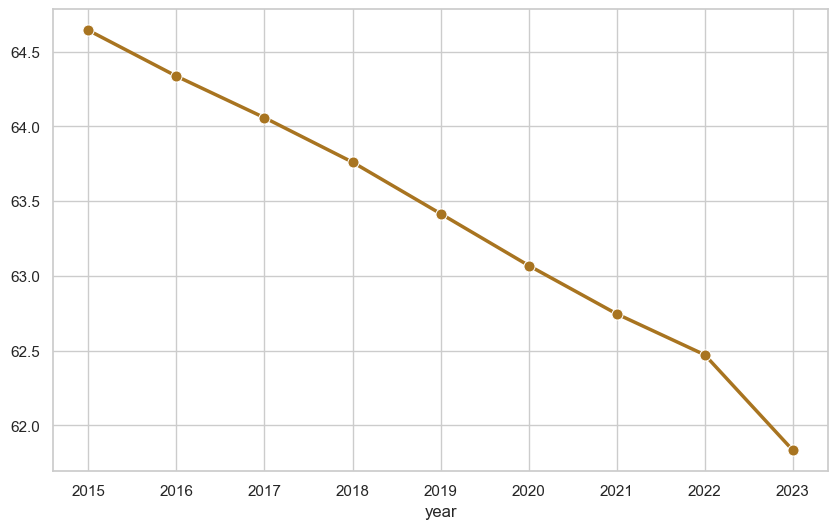

In [46]:
ACTIVE_VARS_FINAL = [
    "happiness_score",
    "gdp_log",
    "life_expectancy",
    "freedom_to_choose",
    "generosity",
    "cpi",
    "unemployment_rate",
    "active_population_rate",
    "urban_population_rate",
    "voice_accountability",
    "government_effectiveness",
    "co2_emissions_per_capita",
    "temperature_change_from_ghg",
]

VAR_CONFIG, COLS_NUM = make_config(ACTIVE_VARS_FINAL)

print("génération des profils mondiaux")
generate_global_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL, YEAR_MIN, YEAR_MAX)

print("génération des profils régionaux")
generate_regional_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL, YEAR_MIN, YEAR_MAX)

print("génération des profils nationaux")
generate_country_profiles(df_combined_raw, COLS_NUM, VAR_CONFIG, PROFIL, YEAR_MIN, YEAR_MAX)

### Conclusion de la Section 2

Dans cette section, j’ai nettoyé et standardisé le fichier `world_happiness_combined.csv` afin d’obtenir un panel exploitable pour des analyses comparables entre pays et dans le temps.

D’abord, j’ai identifié des valeurs manquantes sur la variable `Regional indicator`. Plutôt que de corriger à la main, j’ai remplacé cette variable par une classification externe plus fiable : une table de régions issue d’un fichier `UNSD` (`regions.csv`). Après harmonisation des noms de pays avec `clean_name`, j’ai fusionné cette table au dataset. Seuls 6 pays n’avaient pas de région et ont été renseignés manuellement (`Kosovo`, `Laos`, `North Cyprus`, `Republic of the Congo`, `Somaliland region`, `Taiwan`). À ce stade, chaque pays est associé à une région unique et cohérente.

Ensuite, j’ai harmonisé les noms de pays et renommé les variables (suppression des espaces et noms plus courts) afin de faciliter les traitements. Pour vérifier la cohérence des données, j’ai généré des profils d’évolution (monde, régions, pays), ce qui a mis en évidence plusieurs variables `Kaggle` non fiables ou non comparables selon les années.

J’ai alors remplacé certaines variables problématiques par des sources externes :

`Perceptions of corruption` a été supprimée et remplacée par `cpi` (`Transparency International`). Les pays sans couverture `CPI` ont été retirés.

`healthy_life_expectancy` a été remplacée par `life_expectancy` (`OWID`). Comme cette source n’est pas disponible pour 2024, l’analyse a été alignée sur 2015–2023.

`gdp_per_capita` a été recalculée via l’API `WDI` (indicateur `NY.GDP.PCAP.PP.KD`), puis transformée en `gdp_log` (log du PIB PPP constant 2017). Les pays avec données manquantes sur cet indicateur ont été retirés.

Enfin, la variable `social_support` a été supprimée car les valeurs du dataset Kaggle présentent une incohérence visible (pic anormal en 2018) et aucune source de substitution satisfaisante n’a été retenue.

Pour enrichir l’analyse, j’ai ajouté de nouvelles variables exogènes :

via `WDI` : `unemployment_rate`, `active_population_rate`, `urban_population_rate`, ainsi que `voice_accountability` et `government_effectiveness`,

via `OWID` : `co2_emissions_per_capita` et `temperature_change_from_ghg`.

À chaque ajout, j’ai contrôlé la couverture avec `report_missing_by_country` et supprimé les pays bloquants (par exemple `Kosovo` et `Ukraine` pour le chômage).

Au final, le dataset nettoyé couvre 2015–2023 et contient 1281 lignes pour 152 pays. Il est ensuite exporté dans `world_happiness_combined_clean.csv` pour servir de base aux analyses suivantes.

##### *SECTION 3 - Analyse descriptive et préparation de l’ACP*

- Choix du jeu de données pour l’ACP

Puis sous R : 
- Chargement des données et sélection des variables
- Standardisation des données et matrice de corrélation
- Décomposition spectrale
- Coordonnées factorielles des individus
- Qualité de représentation des pays sur le plan (1,2)
- Coordonnées factorielles des variables
- Cercle des corrélations (plan 1,2)

Pour l'ACP, on se limite aux pays présents sur toute la décennie (`df_clean_decade`) afin de garantir une base d’analyse homogène. 

- ##### Filtrage des pays présents pour toute la décennie

In [47]:
years_expected = set(range(YEAR_MIN, YEAR_MAX + 1))

# Variables actives prévues pour l'ACP
ACP_VARS = [
    "happiness_score",
    "gdp_log",
    "life_expectancy",
    "freedom_to_choose",
    "generosity",
    "cpi",
    "unemployment_rate",
    "active_population_rate",
    "urban_population_rate",
    "voice_accountability",
    "government_effectiveness",
    "co2_emissions_per_capita",
    "temperature_change_from_ghg",
]

ACP_VARS = [c for c in ACP_VARS if c in df_combined_raw.columns]

# Pays complets: toutes les années + aucune NA sur les variables ACP
countries_full = (
    df_combined_raw.groupby("country")
    .apply(lambda g: (set(g["year"]) == years_expected) and g[ACP_VARS].notna().all().all())
)

countries_full = countries_full[countries_full].index.tolist()

df_clean_decade = df_combined_raw[df_combined_raw["country"].isin(countries_full)].copy()

print("Panel équilibré:")
print("- Nb pays :", df_clean_decade["country"].nunique())
print("- Nb lignes :", len(df_clean_decade))
print("- Période :", df_clean_decade["year"].min(), "->", df_clean_decade["year"].max())


Panel équilibré:
- Nb pays : 125
- Nb lignes : 1125
- Période : 2015 -> 2023


C:\Users\antoc\AppData\Local\Temp\ipykernel_26240\1732737705.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (set(g["year"]) == years_expected) and g[ACP_VARS].notna().all().all())


- ##### Choix du jeu de données pour l’ACP

Pour la première ACP, on peut se concentrer sur une année (par exemple 2015), puis comparer les résultats issus d'une seconde ACP, avec une année récente comme 2024.

In [ ]:
df_2015 = df_clean_decade[df_clean_decade["year"] == 2015].copy()
df_2020 = df_clean_decade[df_clean_decade["year"] == 2020].copy()
df_2023 = df_clean_decade[df_clean_decade["year"] == 2023].copy()

CLEAN_2015 = "../data/clean/world_happiness_2015_clean.csv"
CLEAN_2020 = "../data/clean/world_happiness_2020_clean.csv"
CLEAN_2023 = "../data/clean/world_happiness_2023_clean.csv"

df_2015.to_csv(CLEAN_2015, sep=";", index=False, encoding="utf-8")
df_2020.to_csv(CLEAN_2020, sep=";", index=False, encoding="utf-8")
df_2023.to_csv(CLEAN_2023, sep=";", index=False, encoding="utf-8")

print("Fichiers ACP sauvegardés :")
print("-", CLEAN_2015)
print("-", CLEAN_2020)
print("-", CLEAN_2023)

Fichiers ACP sauvegardés :
- ../data/clean/world_happiness_2015_clean.csv
- ../data/clean/world_happiness_2020_clean.csv
- ../data/clean/world_happiness_2023_clean.csv


L’Analyse en Composantes Principales (`ACP`) est réalisée sous R, dans un notebook dédié `ACP.qmd`.